In [33]:
"""
opr_7_post_processing.ipynb
Post-processing pipeline for evaluation data.

STAGE 1: Normalize fallback values to empty string
STAGE 2: Merge separated labels (tipo1 + tipo2 → tipo)
STAGE 3: Coarsen categories using taxonomy.json mappings
"""
import json
from pathlib import Path

import pandas as pd

# === PATHS ===
# OLD: non-conversational evaluation (by victim)
INPUT_PATH_OLD = Path("df_text_multi_eval_by_victim.csv")
# NEW: conversational evaluation (by report)
INPUT_PATH_NEW = Path("results_large_models/df_text_by_report_conversation_evaluation.csv")
TAXONOMY_PATH = Path("config/taxonomy.json")

# === CONSTANTS ===
CLASSIFICATION_SUFFIX = "_classification"

# Label column base names
LABEL_KEYS = [
    "vic_grupo_social", "amenaza_quien", "captura_metodo", "captura_tipo",
    "cautiverio_trato", "desenlace", "desenlace_tipo",
    "perp_tipo1", "perp_tipo2",
    "proced_contacto1", "proced_contacto2", "proced_contactado",
    "Tribunal_tipo", "proced_sent_tipo", "soc_civil",
]

# Pairs to merge: (col1, col2, merged_name)
SEPARATED_LABEL_PAIRS = [
    ("perp_tipo1", "perp_tipo2", "perp_tipo"),
    ("proced_contacto1", "proced_contacto2", "proced_contacto"),
]

In [34]:
# === LOAD DATA ===
# OLD: non-conversational evaluation (by victim)
df_nonconv = pd.read_csv(INPUT_PATH_OLD, encoding="utf-8")
print(f"Loaded {len(df_nonconv)} rows from {INPUT_PATH_OLD} (OLD/non-conv)")

# NEW: conversational evaluation (by report)
df_raw = pd.read_csv(INPUT_PATH_NEW, encoding="utf-8")
print(f"Loaded {len(df_raw)} rows from {INPUT_PATH_NEW} (NEW/conv)")

# Filter: keep last VALID report per victim (fallback to last if all invalid)
def get_last_valid_or_last(group):
    valid = group[group["summary_all_context"].notna() & (group["summary_all_context"] != "")]
    if len(valid) > 0:
        return valid.tail(1)
    else:
        return group.tail(1)

df_raw = (
    df_raw.sort_values(by=["victim", "index"])
    .groupby("victim", as_index=False)
    .apply(get_last_valid_or_last)
    .reset_index(drop=True)
)
print(f"After filtering to last valid report per victim: {len(df_raw)} rows")

# === LOAD TAXONOMY ===
with open(TAXONOMY_PATH, "r", encoding="utf-8") as f:
    taxonomy = json.load(f)

FALLBACK_VALUES = set(taxonomy["fallback_values"])
FALLBACK_VALUES_LOWER = {v.lower() for v in FALLBACK_VALUES}
CATEGORY_MERGING = taxonomy["category_merging"]
NO_COARSENING_FIELDS = set(taxonomy["no_coarsening_fields"])

print(f"Fallback values: {len(FALLBACK_VALUES)}")
print(f"Category merging fields: {list(CATEGORY_MERGING.keys())}")
print(f"No coarsening: {NO_COARSENING_FIELDS}")

Loaded 1633 rows from df_text_multi_eval_by_victim.csv (OLD/non-conv)
Loaded 2229 rows from results_large_models\df_text_by_report_conversation_evaluation.csv (NEW/conv)
After filtering to last valid report per victim: 575 rows
Fallback values: 9
Category merging fields: ['perp_tipo', 'captura_metodo', 'proced_contactado', 'desenlace', 'captura_tipo', 'desenlace_tipo', 'vic_grupo_social', 'amenaza_quien', 'cautiverio_trato', 'proced_sent_tipo']
No coarsening: {'Tribunal_tipo', 'proced_contacto', 'soc_civil'}


C:\Users\meier\AppData\Local\Temp\ipykernel_11604\3604687040.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_last_valid_or_last)


In [35]:
# =============================================================================
# STAGE 1: NORMALIZE VALUES
# =============================================================================
# 1. NaN → ""
# 2. Strip parenthetical suffixes: "Foo (bar explanation)" → "Foo"
#    This handles LLM outputs that omit the parenthetical part.

import re

def normalize_value(value) -> str:
    """Normalize a label value: NaN → '', strip parentheses suffix."""
    if pd.isna(value):
        return ""
    value_str = str(value).strip()
    if not value_str:
        return ""
    # Remove parenthetical suffix: "Foo (bar)" → "Foo"
    match = re.match(r'^(.+?)\s*\([^)]+\)\s*$', value_str)
    if match:
        return match.group(1).strip()
    return value_str


# Build columns to normalize
columns_to_normalize = []
for key in LABEL_KEYS:
    columns_to_normalize.append(key)
    columns_to_normalize.append(f"{key}{CLASSIFICATION_SUFFIX}")

# Apply normalization
df_stage1 = df_raw.copy()
nan_count = 0
paren_count = 0

for col in columns_to_normalize:
    if col not in df_stage1.columns:
        continue
    
    # Count NaN before
    nan_count += df_stage1[col].isna().sum()
    
    # Count values with parentheses before normalization
    non_null = df_stage1[col].dropna().astype(str)
    paren_count += non_null.str.contains(r'\([^)]+\)$', regex=True).sum()
    
    # Apply normalization
    df_stage1[col] = df_stage1[col].apply(normalize_value)

print(f"Stage 1 complete:")
print(f"  NaN → '':              {nan_count}")
print(f"  Parentheses removed:   {paren_count}")

Stage 1 complete:
  NaN → '':              12110
  Parentheses removed:   1506


In [36]:
# =============================================================================
# STAGE 0.1: EXCLUDE VERACRUZ CASES (lacking proper annotations)
# =============================================================================
n_old_before = len(df_nonconv)
n_new_before = len(df_raw)

df_nonconv = df_nonconv[~df_nonconv["victim"].str.startswith("Veracruz")]
df_raw = df_raw[~df_raw["victim"].str.startswith("Veracruz")]

print("Stage 0.1: Excluded Veracruz cases")
print(f"  OLD: {n_old_before} → {len(df_nonconv)} (-{n_old_before - len(df_nonconv)})")
print(f"  NEW: {n_new_before} → {len(df_raw)} (-{n_new_before - len(df_raw)})")

Stage 0.1: Excluded Veracruz cases
  OLD: 1633 → 1359 (-274)
  NEW: 575 → 453 (-122)


In [37]:
# =============================================================================
# STAGE 2: MERGE SEPARATED LABELS
# =============================================================================
# Combine: perp_tipo1 + perp_tipo2 → perp_tipo (list)
#          proced_contacto1 + proced_contacto2 → proced_contacto (list)

def merge_label_columns(row, col1: str, col2: str) -> list:
    """Merge two label columns into a list of non-empty values."""
    values = []
    for col in [col1, col2]:
        val = row.get(col, "")
        if val and str(val).strip():
            values.append(str(val).strip())
    return values


df_stage2 = df_stage1.copy()

for col1, col2, merged_name in SEPARATED_LABEL_PAIRS:
    # Merge human columns
    if col1 in df_stage2.columns and col2 in df_stage2.columns:
        df_stage2[merged_name] = df_stage2.apply(
            lambda row, c1=col1, c2=col2: merge_label_columns(row, c1, c2), axis=1
        )
        print(f"Merged: {col1} + {col2} → {merged_name}")

    # Merge classification columns
    col1_cls = f"{col1}{CLASSIFICATION_SUFFIX}"
    col2_cls = f"{col2}{CLASSIFICATION_SUFFIX}"
    merged_cls = f"{merged_name}{CLASSIFICATION_SUFFIX}"

    if col1_cls in df_stage2.columns and col2_cls in df_stage2.columns:
        df_stage2[merged_cls] = df_stage2.apply(
            lambda row, c1=col1_cls, c2=col2_cls: merge_label_columns(row, c1, c2), axis=1
        )
        print(f"Merged: {col1_cls} + {col2_cls} → {merged_cls}")

print(f"\nStage 2 complete. Shape: {df_stage2.shape}")

Merged: perp_tipo1 + perp_tipo2 → perp_tipo
Merged: perp_tipo1_classification + perp_tipo2_classification → perp_tipo_classification
Merged: proced_contacto1 + proced_contacto2 → proced_contacto
Merged: proced_contacto1_classification + proced_contacto2_classification → proced_contacto_classification

Stage 2 complete. Shape: (575, 56)


In [38]:
# =============================================================================
# STAGE 3: CATEGORY COARSENING
# =============================================================================
# Apply category_merging from taxonomy.json to consolidate fine-grained labels.

def apply_coarsening(value, mapping: dict):
    """Map value to coarsened category. Return as-is if not in mapping."""
    # Handle list values first (from merged columns)
    if isinstance(value, list):
        return [mapping.get(v, v) for v in value if v]
    # Handle scalar values
    if pd.isna(value) or value == "":
        return value
    return mapping.get(value, value)


# Build column-to-mapping lookup
# perp_tipo in config → apply to merged perp_tipo list
COLUMN_MAPPING = {}
for field, mapping in CATEGORY_MERGING.items():
    if field not in NO_COARSENING_FIELDS:
        COLUMN_MAPPING[field] = mapping

# Apply coarsening
df_stage3 = df_stage2.copy()
coarsened_count = 0

for col_base, mapping in COLUMN_MAPPING.items():
    # Human column
    if col_base in df_stage3.columns:
        df_stage3[col_base] = df_stage3[col_base].apply(
            lambda v, m=mapping: apply_coarsening(v, m)
        )
        coarsened_count += 1

    # Classification column
    col_cls = f"{col_base}{CLASSIFICATION_SUFFIX}"
    if col_cls in df_stage3.columns:
        df_stage3[col_cls] = df_stage3[col_cls].apply(
            lambda v, m=mapping: apply_coarsening(v, m)
        )
        coarsened_count += 1

print(f"Stage 3 complete. Applied coarsening to {coarsened_count} columns.")
print(f"df_stage3 shape: {df_stage3.shape}")

Stage 3 complete. Applied coarsening to 20 columns.
df_stage3 shape: (575, 56)


In [39]:
# =============================================================================
# STAGE 4: UPDATE *_match COLUMNS
# =============================================================================
# Recalculate match columns based on post-processed human and classification values.
# Match = 1 if human == classification, else 0.

def to_set(val) -> set:
    """Convert value to set, filtering empty/nan values."""
    if isinstance(val, list):
        return {str(v).strip() for v in val if v and str(v).strip()}
    if pd.isna(val) or not str(val).strip():
        return set()
    return {str(val).strip()}


def values_match(human_val, machine_val) -> int:
    """Compare human and machine values, return 1 if match, 0 otherwise."""
    human_set = to_set(human_val)
    machine_set = to_set(machine_val)
    # Both empty = match (no information on either side)
    # Both non-empty = compare sets (order/duplicate independent)
    return 1 if human_set == machine_set else 0


# Labels to compare (after merging: use perp_tipo instead of perp_tipo1/2)
MATCH_LABELS = [
    "vic_grupo_social", "amenaza_quien", "captura_metodo", "captura_tipo",
    "cautiverio_trato", "desenlace", "desenlace_tipo",
    "perp_tipo", "proced_contacto", "proced_contactado",
    "Tribunal_tipo", "proced_sent_tipo", "soc_civil",
]

# Sort and deduplicate merged list columns for consistent comparison
MERGED_LIST_COLS = list(taxonomy.get("merged_label_pairs", {}).keys())

def dedupe_list(val):
    """Sort and deduplicate list values."""
    if isinstance(val, list):
        return sorted(set(v for v in val if v))
    return val

for col_base in MERGED_LIST_COLS:
    for col in [col_base, f"{col_base}{CLASSIFICATION_SUFFIX}"]:
        if col in df_stage3.columns:
            df_stage3[col] = df_stage3[col].apply(dedupe_list)

# Recalculate match columns
for label in MATCH_LABELS:
    human_col = label
    machine_col = f"{label}{CLASSIFICATION_SUFFIX}"
    match_col = f"{label}_match"
    
    if human_col in df_stage3.columns and machine_col in df_stage3.columns:
        df_stage3[match_col] = df_stage3.apply(
            lambda row, h=human_col, m=machine_col: values_match(row[h], row[m]),
            axis=1
        )
        print(f"{match_col}: {df_stage3[match_col].sum()}/{len(df_stage3)} matches")

print(f"\nStage 4 complete. Updated match columns.")

vic_grupo_social_match: 281/575 matches
amenaza_quien_match: 454/575 matches
captura_metodo_match: 158/575 matches
captura_tipo_match: 282/575 matches
cautiverio_trato_match: 459/575 matches
desenlace_match: 224/575 matches
desenlace_tipo_match: 302/575 matches
perp_tipo_match: 293/575 matches
proced_contacto_match: 243/575 matches
proced_contactado_match: 209/575 matches
Tribunal_tipo_match: 439/575 matches
proced_sent_tipo_match: 548/575 matches
soc_civil_match: 148/575 matches

Stage 4 complete. Updated match columns.


In [40]:
# === VERIFICATION: BEFORE vs AFTER ===

print("=== proced_contacto: BEFORE (raw) vs AFTER (merged + coarsened) ===")
print("BEFORE (proced_contacto1):", df_raw["proced_contacto1"].head(10).tolist())
print("BEFORE (proced_contacto2):", df_raw["proced_contacto2"].head(10).tolist())
print("AFTER  (proced_contacto):", df_stage3["proced_contacto"].head(10).tolist())

print("\n=== captura_metodo: BEFORE vs AFTER ===")
print("BEFORE:", df_raw["captura_metodo"].value_counts().head(10).to_dict())
print("AFTER:", df_stage3["captura_metodo"].value_counts().head(10).to_dict())

print("\n=== desenlace: BEFORE vs AFTER ===")
print("BEFORE:", df_raw["desenlace"].value_counts().head(10).to_dict())
print("AFTER:", df_stage3["desenlace"].value_counts().head(10).to_dict())

# === MATCH COLUMNS: BEFORE vs AFTER ===
print("\n" + "="*60)
print("=== MATCH COLUMNS: BEFORE vs AFTER ===")
print("="*60)

# Compare match rates for labels that exist in both raw and processed
# Format: (raw_col, new_col)
COMPARE_LABELS = [
    ("vic_grupo_social_match", "vic_grupo_social_match"),
    ("amenaza_quien_match", "amenaza_quien_match"),
    ("captura_metodo_match", "captura_metodo_match"),
    ("captura_tipo_match", "captura_tipo_match"),
    ("cautiverio_trato_match", "cautiverio_trato_match"),
    ("desenlace_match", "desenlace_match"),
    ("desenlace_tipo_match", "desenlace_tipo_match"),
    ("perp_tipo1_match", "perp_tipo_match"),  # merged: tipo1+tipo2 → tipo
    ("proced_contacto1_match", "proced_contacto_match"),  # merged: contacto1+contacto2 → contacto
    ("proced_contactado_match", "proced_contactado_match"),
    ("Tribunal_tipo_match", "Tribunal_tipo_match"),
    ("proced_sent_tipo_match", "proced_sent_tipo_match"),
    ("soc_civil_match", "soc_civil_match"),
]

print(f"{'Label':<30} {'BEFORE':>10} {'AFTER':>10} {'Δ':>10}")
print("-" * 60)
for raw_col, new_col in COMPARE_LABELS:
    if raw_col in df_raw.columns and new_col in df_stage3.columns:
        before = df_raw[raw_col].sum()
        after = df_stage3[new_col].sum()
        delta = after - before
        print(f"{new_col:<30} {before:>10} {after:>10} {delta:>+10}")

=== proced_contacto: BEFORE (raw) vs AFTER (merged + coarsened) ===
BEFORE (proced_contacto1): ['Relatives', 'Relatives', 'Relatives', 'Relatives', nan, 'Relatives', 'Relatives', 'Relatives', 'Relatives', 'Relatives']
BEFORE (proced_contacto2): [nan, nan, nan, nan, nan, 'Relatives', nan, nan, nan, nan]
AFTER  (proced_contacto): [['Relatives'], ['Relatives'], ['Relatives'], ['Relatives'], [], ['Relatives'], ['Relatives'], ['Relatives'], ['Relatives'], ['Relatives']]

=== captura_metodo: BEFORE vs AFTER ===
BEFORE: {'Disappearance': 249, 'Levantón (kidnapping but pejorative use towards the victim)': 74, 'Kidnapping': 56, 'Detention/arrest': 21, 'Military or political operation (raid)': 9, 'Scam': 6, 'Plagio (kidnapping in a legal sense)': 3}
AFTER: {'Disappearance': 249, '': 157, 'Levantón': 74, 'Kidnapping': 56, 'Official detention': 21, 'Military or political operation': 9, 'Scam': 6, 'Plagio': 3}

=== desenlace: BEFORE vs AFTER ===
BEFORE: {'Still disappeared': 254, 'Found dead': 91, 

In [41]:
# =============================================================================
# DEBUG: Compare BEFORE vs AFTER for any label
# =============================================================================
# Change LABEL to debug different fields

LABEL = "perp_tipo"  # <-- CHANGE THIS: perp_tipo, proced_contacto, etc.

# Determine if this is a merged label (has 1/2 suffix in raw data)
is_merged = LABEL in ["perp_tipo", "proced_contacto"]

if is_merged:
    before_col = f"{LABEL}1_match"
    raw_h1, raw_h2 = f"{LABEL}1", f"{LABEL}2"
    raw_l1, raw_l2 = f"{LABEL}1_classification", f"{LABEL}2_classification"
else:
    before_col = f"{LABEL}_match"
    raw_h1, raw_h2 = LABEL, None
    raw_l1, raw_l2 = f"{LABEL}_classification", None

after_col = f"{LABEL}_match"

before_match = df_raw[before_col] == 1
after_match = df_stage3[after_col] == 1

lost = before_match & ~after_match
gained = ~before_match & after_match

print(f"=== {LABEL} ===")
print(f"Lost matches (BEFORE=1, AFTER=0):   {lost.sum()}")
print(f"Gained matches (BEFORE=0, AFTER=1): {gained.sum()}")
print(f"Net change: {gained.sum() - lost.sum():+d}\n")

# Build debug DataFrame
if is_merged:
    df_debug = pd.DataFrame({
        "index": df_raw.loc[lost, "index"],
        "human_1 (raw)": df_raw.loc[lost, raw_h1],
        "human_2 (raw)": df_raw.loc[lost, raw_h2],
        "llm_1 (raw)": df_raw.loc[lost, raw_l1],
        "llm_2 (raw)": df_raw.loc[lost, raw_l2],
        "human (merged)": df_stage3.loc[lost, LABEL],
        "llm (merged)": df_stage3.loc[lost, f"{LABEL}_classification"],
    })
else:
    df_debug = pd.DataFrame({
        "index": df_raw.loc[lost, "index"],
        "human (raw)": df_raw.loc[lost, raw_h1],
        "llm (raw)": df_raw.loc[lost, raw_l1],
        "human (after)": df_stage3.loc[lost, LABEL],
        "llm (after)": df_stage3.loc[lost, f"{LABEL}_classification"],
    })

print("=== LOST MATCHES (first 15) ===")
print(df_debug.head(15).to_string(index=False))

=== perp_tipo ===
Lost matches (BEFORE=1, AFTER=0):   8
Gained matches (BEFORE=0, AFTER=1): 3
Net change: -5

=== LOST MATCHES (first 15) ===
                        index    human_1 (raw)                                                                   human_2 (raw)      llm_1 (raw)         llm_2 (raw)                      human (merged)                        llm (merged)
      Coahuila_Ezequiel C T_8 Municipal police                                                             Organized crime (Z) Municipal police    Municipal police [Organized crime, State-affiliated]                  [State-affiliated]
        Coahuila_Griselda G_1              NaN                                                                             NaN              NaN    Municipal police                                  []                  [State-affiliated]
 Coahuila_Heber Eusebio R R_1 Municipal police                                                                             NaN Municipal police Organi

=== OLD (df_nonconv, non-conversational) ===


,Accuracy,Precision,Recall,F1 (macro),Cohen Kappa
vic_grupo_social,0.387785,0.204695,0.313321,0.208972,0.246476
amenaza_quien,0.439294,0.067237,0.105808,0.049159,0.021140
captura_metodo,0.415747,0.099207,0.084236,0.082933,0.184995
captura_tipo,0.249448,0.100172,0.094092,0.080078,0.091760
cautiverio_trato,0.636497,0.168367,0.236659,0.163606,0.063466
desenlace,0.537896,0.396349,0.295773,0.320686,0.305562
desenlace_tipo,0.184695,0.083679,0.102240,0.057984,0.036688
perp_tipo1,0.361295,0.158234,0.128996,0.127255,0.179522
perp_tipo2,0.375276,0.034580,0.034632,0.028064,0.042486
proced_contacto1,0.435614,0.067960,0.095141,0.072095,0.102776



=== NEW (df_stage3, conversational + post-processed) ===


,Accuracy,Precision,Recall,F1 (macro),Cohen Kappa
vic_grupo_social,0.488696,0.317453,0.293718,0.266648,0.130437
amenaza_quien,0.789565,0.211901,0.277738,0.205039,0.030435
captura_metodo,0.274783,0.166350,0.143151,0.137452,0.001449
captura_tipo,0.490435,0.273720,0.259349,0.258474,0.026302
cautiverio_trato,0.798261,0.408316,0.312956,0.339775,0.005428
desenlace,0.389565,0.492054,0.404271,0.372395,0.094582
desenlace_tipo,0.525217,0.252960,0.262290,0.233389,-0.016329
perp_tipo,0.509565,0.086411,0.092236,0.083293,0.022168
proced_contacto,0.422609,0.081799,0.092780,0.079431,0.044310
proced_contactado,0.363478,0.107387,0.112509,0.107603,0.018364



=== DIFF (Conversational - Non-Conversational) ===
Note: perp_tipo and proced_contacto compare to avg of tipo1/tipo2


,Δ Accuracy,Δ Precision,Δ Recall,Δ F1 (macro),Δ Cohen Kappa
vic_grupo_social,0.100911,0.112758,-0.019602,0.057675,-0.116039
amenaza_quien,0.350272,0.144664,0.171930,0.155880,0.009295
captura_metodo,-0.140964,0.067142,0.058915,0.054519,-0.183546
captura_tipo,0.240987,0.173548,0.165257,0.178395,-0.065457
cautiverio_trato,0.161763,0.239950,0.076297,0.176169,-0.058038
desenlace,-0.148330,0.095705,0.108498,0.051709,-0.210981
desenlace_tipo,0.340523,0.169281,0.160050,0.175405,-0.053017
proced_contactado,0.199387,0.081116,0.082058,0.081406,-0.014026
Tribunal_tipo,0.202036,0.079668,-0.031212,0.091457,-0.015325
proced_sent_tipo,0.189982,0.062843,0.006503,0.079312,-0.080515


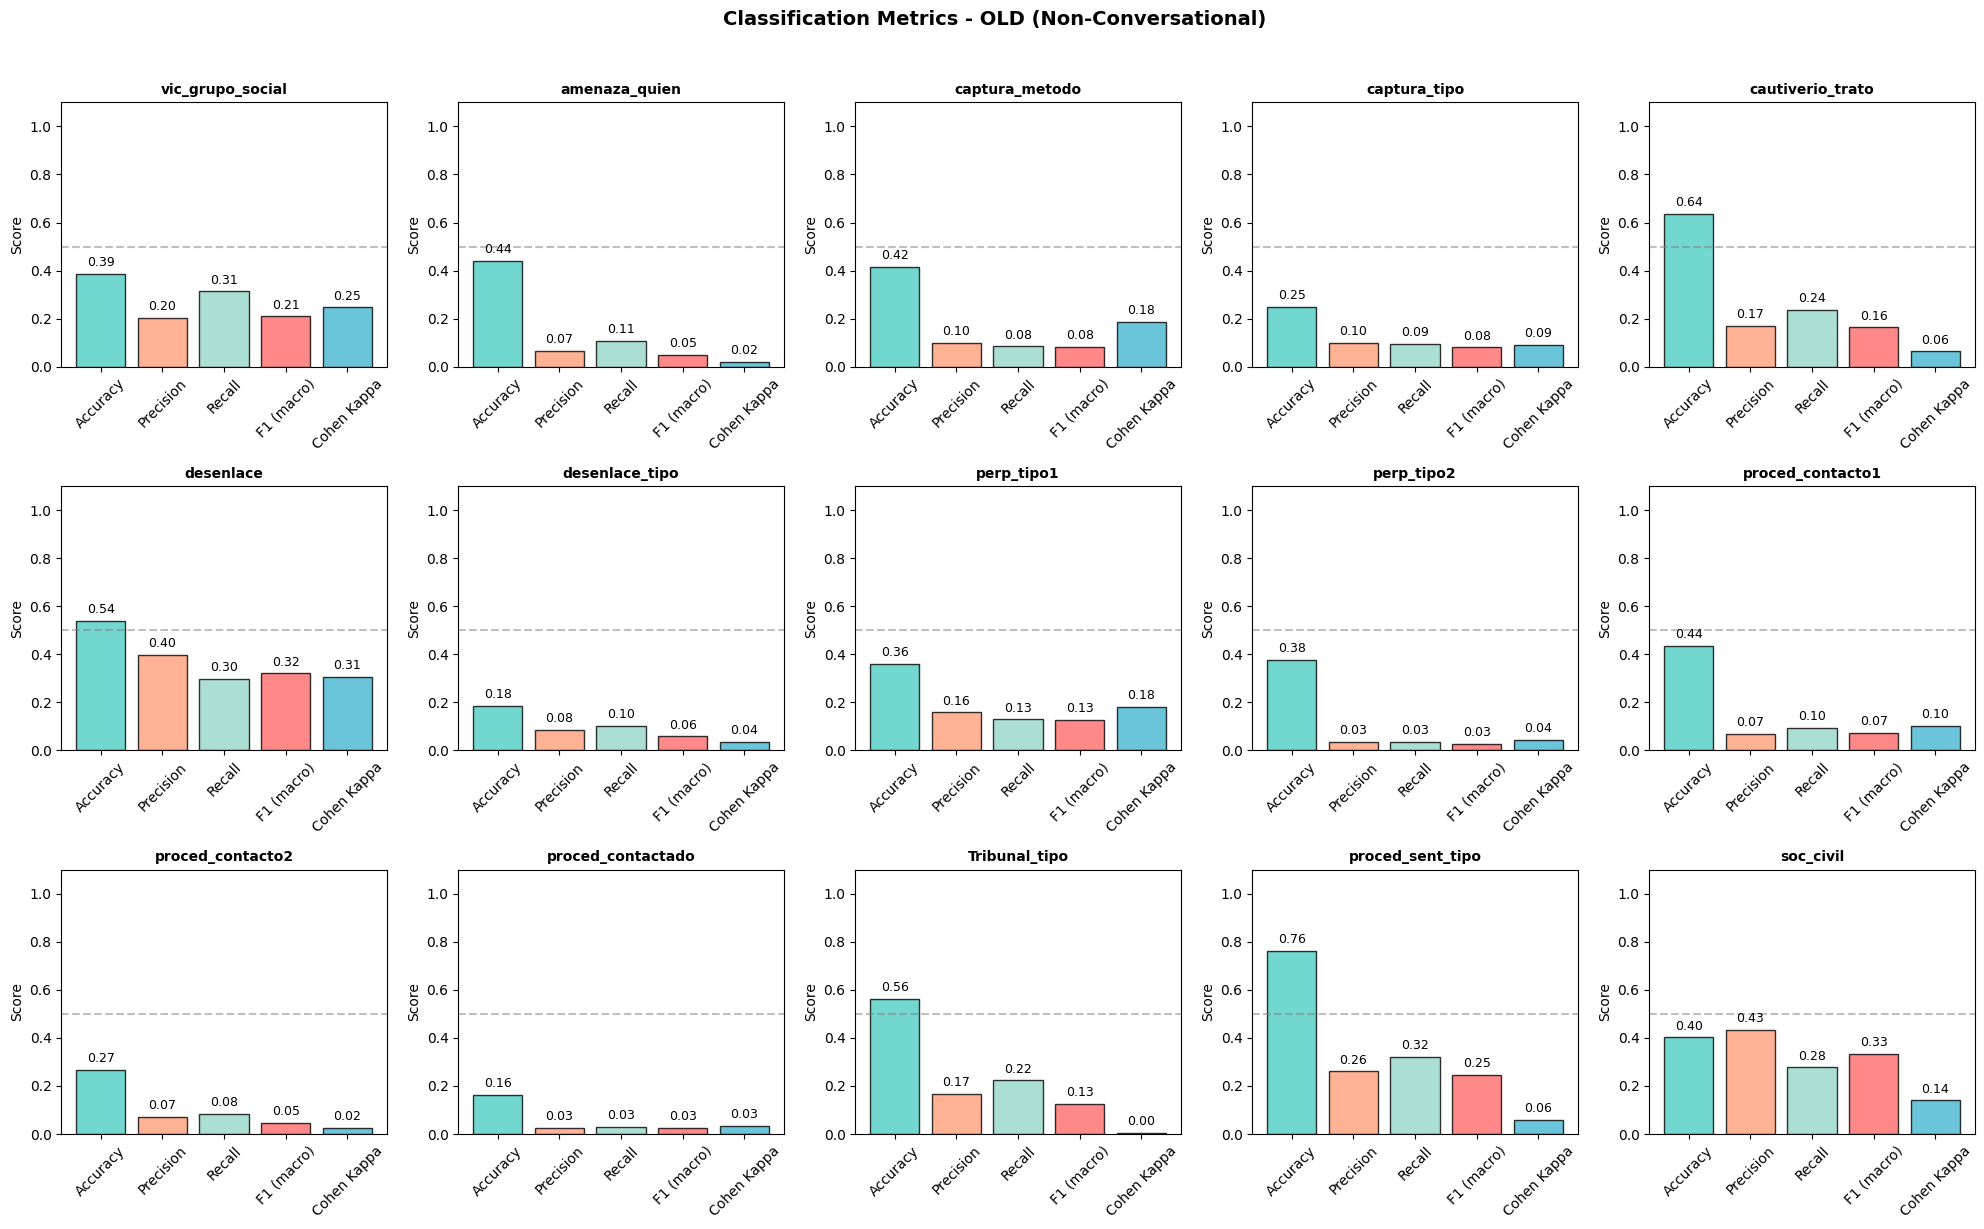

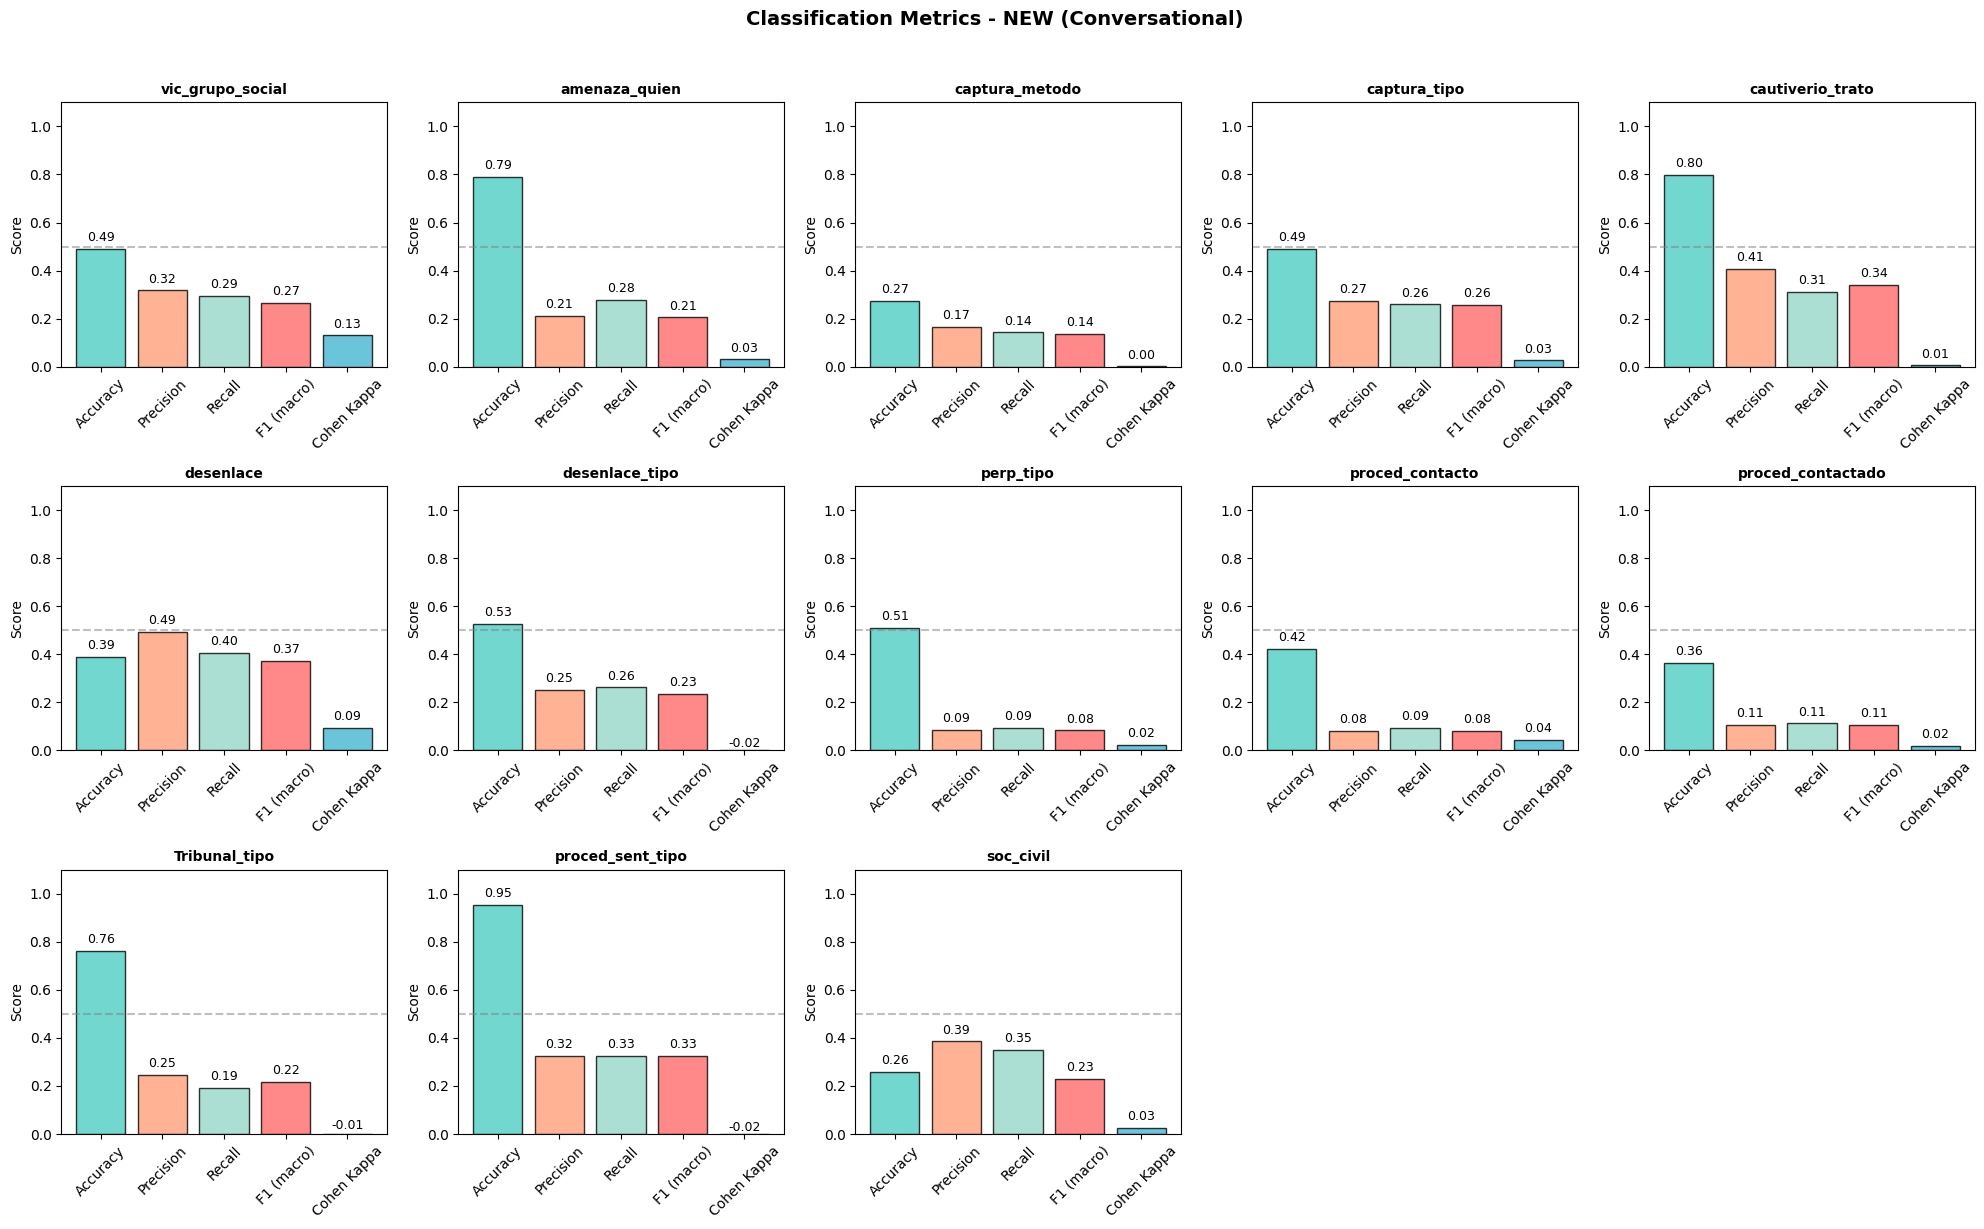

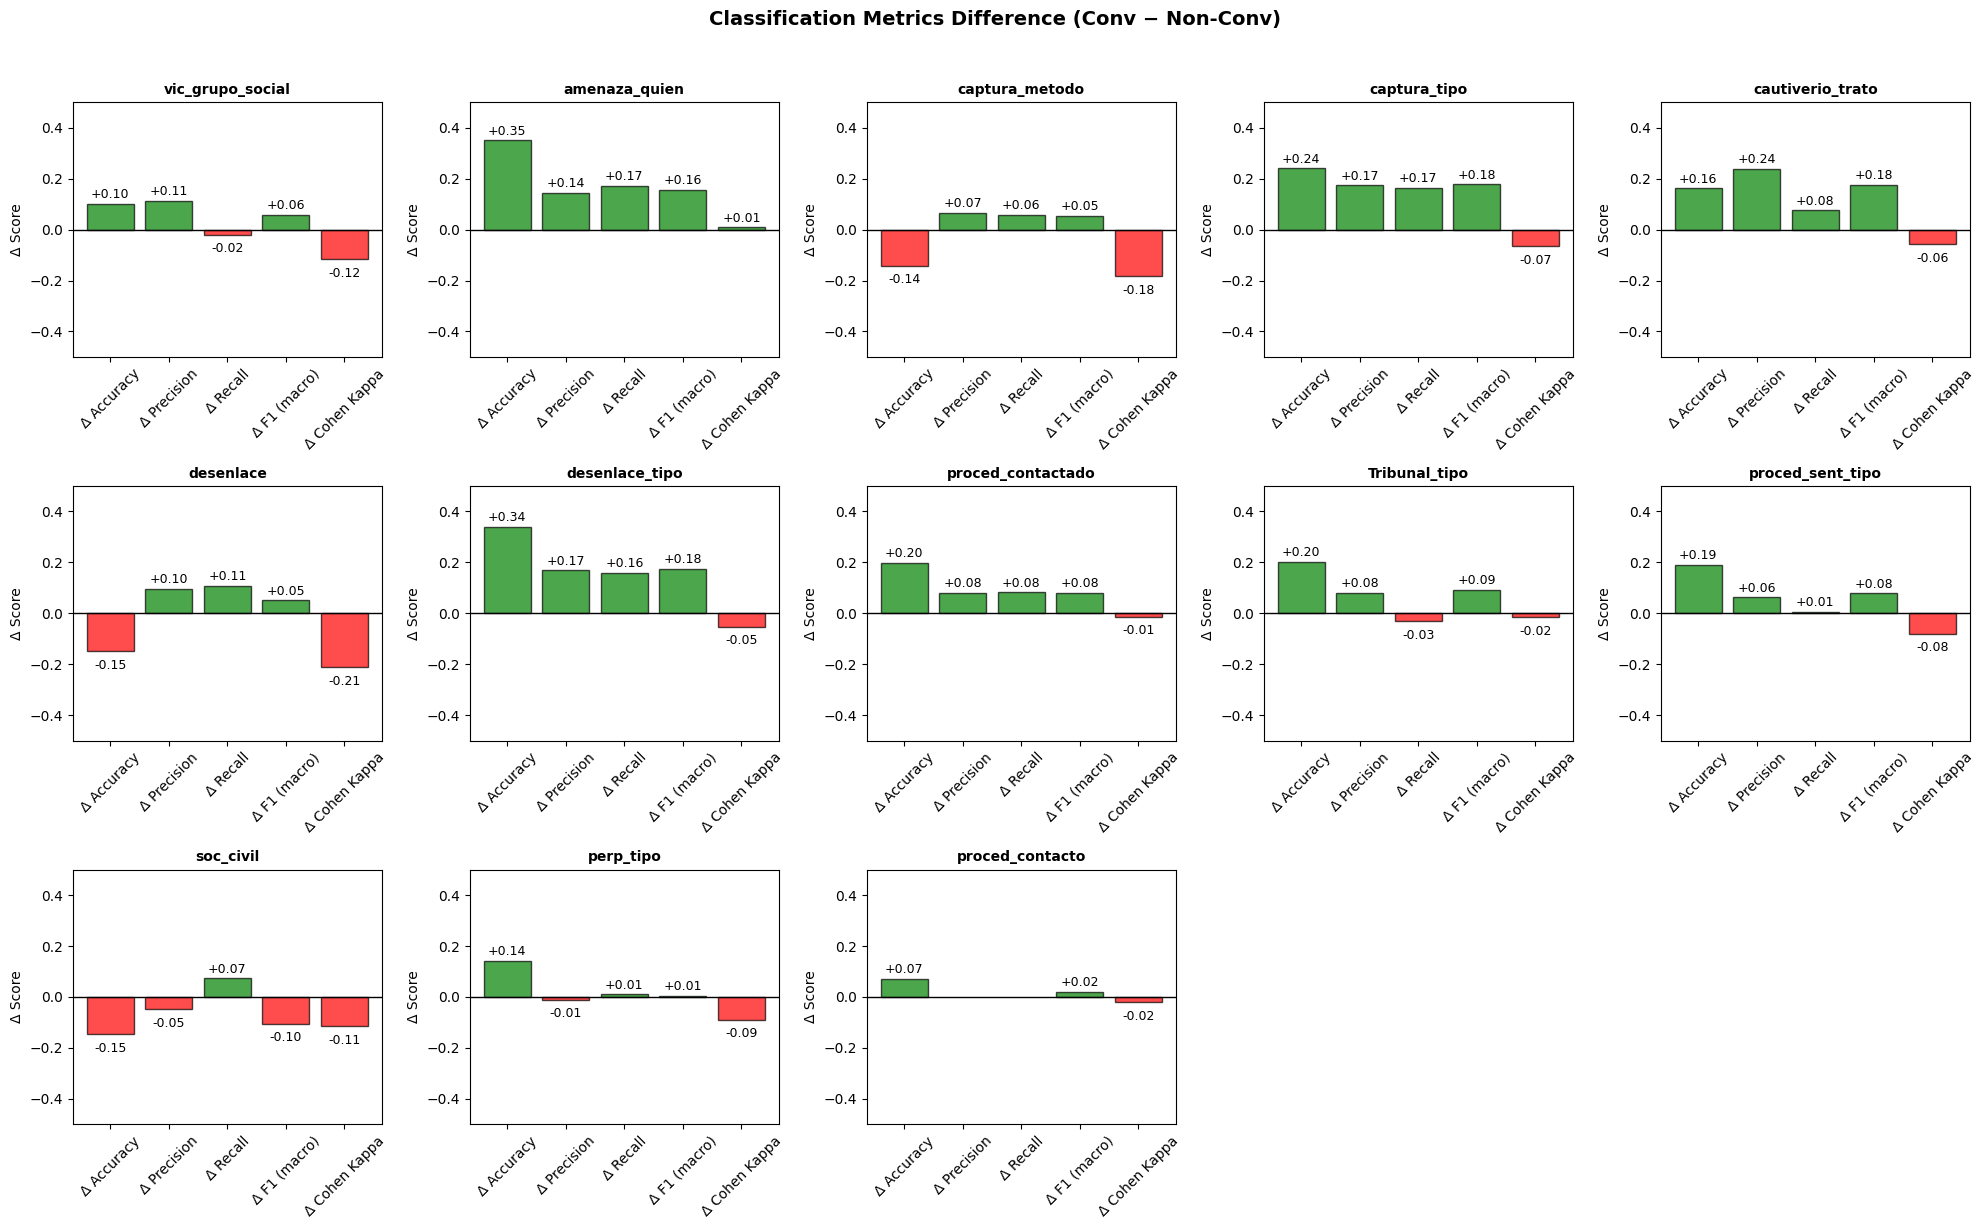

In [42]:
# =============================================================================
# STAGE 5: EVALUATION METRICS - OLD vs NEW vs DIFF
# =============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score

def list_to_str(val) -> str:
    """Convert list/scalar to comparable string. Empty → ''."""
    if isinstance(val, list):
        filtered = sorted([str(v) for v in val if v and str(v).strip()])
        return "|".join(filtered) if filtered else ""
    if pd.isna(val) or not str(val).strip():
        return ""
    return str(val).strip()


def compute_metrics(df, labelling_map: dict) -> dict:
    """Compute Accuracy, Precision, Recall, F1 (macro), Cohen Kappa for each label.
    
    All rows participate in calculation, including empty values.
    Empty vs Empty = match, Empty vs Non-empty = no match.
    """
    metrics = {}
    for human_col, machine_col in labelling_map.items():
        if human_col not in df.columns or machine_col not in df.columns:
            continue
        # Convert to comparable strings (empty → "" which is a valid category)
        human_vals = df[human_col].apply(list_to_str)
        machine_vals = df[machine_col].apply(list_to_str)
        
        if len(human_vals) > 0:
            metrics[human_col] = {
                "Accuracy": accuracy_score(human_vals, machine_vals),
                "Precision": precision_score(human_vals, machine_vals, average="macro", zero_division=0),
                "Recall": recall_score(human_vals, machine_vals, average="macro", zero_division=0),
                "F1 (macro)": f1_score(human_vals, machine_vals, average="macro", zero_division=0),
                "Cohen Kappa": cohen_kappa_score(human_vals, machine_vals),
            }
    return metrics


# === OLD DF (df_nonconv): non-conversational evaluation ===
OLD_LABELLING_MAP = {
    "vic_grupo_social": "vic_grupo_social_classification",
    "amenaza_quien": "amenaza_quien_classification",
    "captura_metodo": "captura_metodo_classification",
    "captura_tipo": "captura_tipo_classification",
    "cautiverio_trato": "cautiverio_trato_classification",
    "desenlace": "desenlace_classification",
    "desenlace_tipo": "desenlace_tipo_classification",
    "perp_tipo1": "perp_tipo1_classification",
    "perp_tipo2": "perp_tipo2_classification",
    "proced_contacto1": "proced_contacto1_classification",
    "proced_contacto2": "proced_contacto2_classification",
    "proced_contactado": "proced_contactado_classification",
    "Tribunal_tipo": "Tribunal_tipo_classification",
    "proced_sent_tipo": "proced_sent_tipo_classification",
    "soc_civil": "soc_civil_classification",
}

# === NEW DF (df_stage3): conversational evaluation (post-processed) ===
NEW_LABELLING_MAP = {
    "vic_grupo_social": "vic_grupo_social_classification",
    "amenaza_quien": "amenaza_quien_classification",
    "captura_metodo": "captura_metodo_classification",
    "captura_tipo": "captura_tipo_classification",
    "cautiverio_trato": "cautiverio_trato_classification",
    "desenlace": "desenlace_classification",
    "desenlace_tipo": "desenlace_tipo_classification",
    "perp_tipo": "perp_tipo_classification",  # merged
    "proced_contacto": "proced_contacto_classification",  # merged
    "proced_contactado": "proced_contactado_classification",
    "Tribunal_tipo": "Tribunal_tipo_classification",
    "proced_sent_tipo": "proced_sent_tipo_classification",
    "soc_civil": "soc_civil_classification",
}

# Compute metrics
old_metrics = compute_metrics(df_nonconv, OLD_LABELLING_MAP)
new_metrics = compute_metrics(df_stage3, NEW_LABELLING_MAP)

# Convert to DataFrames
df_old = pd.DataFrame(old_metrics).T
df_new = pd.DataFrame(new_metrics).T

print("=== OLD (df_nonconv, non-conversational) ===")
display(df_old)

print("\n=== NEW (df_stage3, conversational + post-processed) ===")
display(df_new)

# === DIFF TABLE ===
# For comparable labels, compute NEW - OLD
# Map old separate labels to merged (average for perp_tipo1/2, proced_contacto1/2)

# Labels that exist in both
COMMON_LABELS = [
    "vic_grupo_social", "amenaza_quien", "captura_metodo", "captura_tipo",
    "cautiverio_trato", "desenlace", "desenlace_tipo", "proced_contactado",
    "Tribunal_tipo", "proced_sent_tipo", "soc_civil",
]

# Build diff data
diff_data = {}
for label in COMMON_LABELS:
    if label in df_old.index and label in df_new.index:
        diff_data[label] = {
            "Δ Accuracy": df_new.loc[label, "Accuracy"] - df_old.loc[label, "Accuracy"],
            "Δ Precision": df_new.loc[label, "Precision"] - df_old.loc[label, "Precision"],
            "Δ Recall": df_new.loc[label, "Recall"] - df_old.loc[label, "Recall"],
            "Δ F1 (macro)": df_new.loc[label, "F1 (macro)"] - df_old.loc[label, "F1 (macro)"],
            "Δ Cohen Kappa": df_new.loc[label, "Cohen Kappa"] - df_old.loc[label, "Cohen Kappa"],
        }

# Handle merged labels: perp_tipo (avg of perp_tipo1, perp_tipo2)
if "perp_tipo" in df_new.index:
    old_perp_avg = {}
    for metric in ["Accuracy", "Precision", "Recall", "F1 (macro)", "Cohen Kappa"]:
        vals = []
        if "perp_tipo1" in df_old.index:
            vals.append(df_old.loc["perp_tipo1", metric])
        if "perp_tipo2" in df_old.index:
            vals.append(df_old.loc["perp_tipo2", metric])
        old_perp_avg[metric] = sum(vals) / len(vals) if vals else 0
    
    diff_data["perp_tipo"] = {
        "Δ Accuracy": df_new.loc["perp_tipo", "Accuracy"] - old_perp_avg["Accuracy"],
        "Δ Precision": df_new.loc["perp_tipo", "Precision"] - old_perp_avg["Precision"],
        "Δ Recall": df_new.loc["perp_tipo", "Recall"] - old_perp_avg["Recall"],
        "Δ F1 (macro)": df_new.loc["perp_tipo", "F1 (macro)"] - old_perp_avg["F1 (macro)"],
        "Δ Cohen Kappa": df_new.loc["perp_tipo", "Cohen Kappa"] - old_perp_avg["Cohen Kappa"],
    }

# Handle merged labels: proced_contacto (avg of proced_contacto1, proced_contacto2)
if "proced_contacto" in df_new.index:
    old_contact_avg = {}
    for metric in ["Accuracy", "F1 (macro)", "Cohen Kappa"]:
        vals = []
        if "proced_contacto1" in df_old.index:
            vals.append(df_old.loc["proced_contacto1", metric])
        if "proced_contacto2" in df_old.index:
            vals.append(df_old.loc["proced_contacto2", metric])
        old_contact_avg[metric] = sum(vals) / len(vals) if vals else 0
    
    diff_data["proced_contacto"] = {
        "Δ Accuracy": df_new.loc["proced_contacto", "Accuracy"] - old_contact_avg["Accuracy"],
        "Δ F1 (macro)": df_new.loc["proced_contacto", "F1 (macro)"] - old_contact_avg["F1 (macro)"],
        "Δ Cohen Kappa": df_new.loc["proced_contacto", "Cohen Kappa"] - old_contact_avg["Cohen Kappa"],
    }

df_diff = pd.DataFrame(diff_data).T

print("\n=== DIFF (Conversational - Non-Conversational) ===")
print("Note: perp_tipo and proced_contacto compare to avg of tipo1/tipo2")
display(df_diff)

# =============================================================================
# PLOT 1: OLD (df_nonconv) metrics - non-conversational
# =============================================================================
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_PATH = Path("plots/large_models")
PLOT_PATH.mkdir(parents=True, exist_ok=True)

def plot_metrics(metrics_df, title: str, filename: str):
    """Plot bar chart for each label showing Accuracy, Precision, Recall, F1, Kappa."""
    n_labels = len(metrics_df)
    n_cols = 5
    n_rows = (n_labels + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()
    
    metric_names = ["Accuracy", "Precision", "Recall", "F1 (macro)", "Cohen Kappa"]
    colors = ["#4ecdc4", "#ffa07a", "#98d8c8", "#ff6b6b", "#45b7d1"]
    
    for idx, label_name in enumerate(metrics_df.index):
        ax = axes[idx]
        values = [metrics_df.loc[label_name, m] for m in metric_names]
        
        bars = ax.bar(metric_names, values, color=colors, edgecolor="black", alpha=0.8)
        
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)
        
        ax.set_ylim(0, 1.1)
        ax.set_title(label_name, fontsize=10, fontweight="bold")
        ax.set_ylabel("Score")
        ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
        ax.tick_params(axis="x", rotation=45)
    
    for idx in range(n_labels, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(PLOT_PATH / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_diff(diff_df, title: str, filename: str):
    """Plot bar chart for metric differences (green=positive, red=negative)."""
    n_labels = len(diff_df)
    n_cols = 5
    n_rows = (n_labels + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()
    
    metric_names = ["Δ Accuracy", "Δ Precision", "Δ Recall", "Δ F1 (macro)", "Δ Cohen Kappa"]
    
    for idx, label_name in enumerate(diff_df.index):
        ax = axes[idx]
        values = [diff_df.loc[label_name, m] for m in metric_names]
        
        bar_colors = ["green" if v >= 0 else "red" for v in values]
        bars = ax.bar(metric_names, values, color=bar_colors, edgecolor="black", alpha=0.7)
        
        for bar, val in zip(bars, values):
            y_pos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
            ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                    f"{val:+.2f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)
        
        ax.set_ylim(-0.5, 0.5)
        ax.set_title(label_name, fontsize=10, fontweight="bold")
        ax.set_ylabel("Δ Score")
        ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
        ax.tick_params(axis="x", rotation=45)
    
    for idx in range(n_labels, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(PLOT_PATH / filename, dpi=150, bbox_inches="tight")
    plt.show()


# Plot all three
plot_metrics(df_old, "Classification Metrics - OLD (Non-Conversational)", "metrics_old_nonconv.png")
plot_metrics(df_new, "Classification Metrics - NEW (Conversational)", "metrics_new_conv.png")
plot_diff(df_diff, "Classification Metrics Difference (Conv − Non-Conv)", "metrics_diff.png")

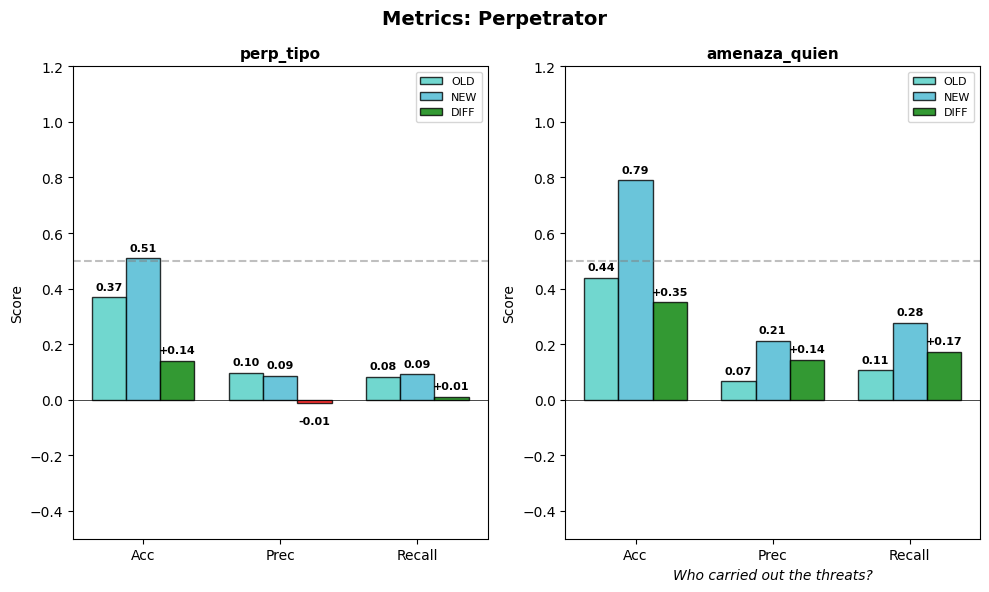

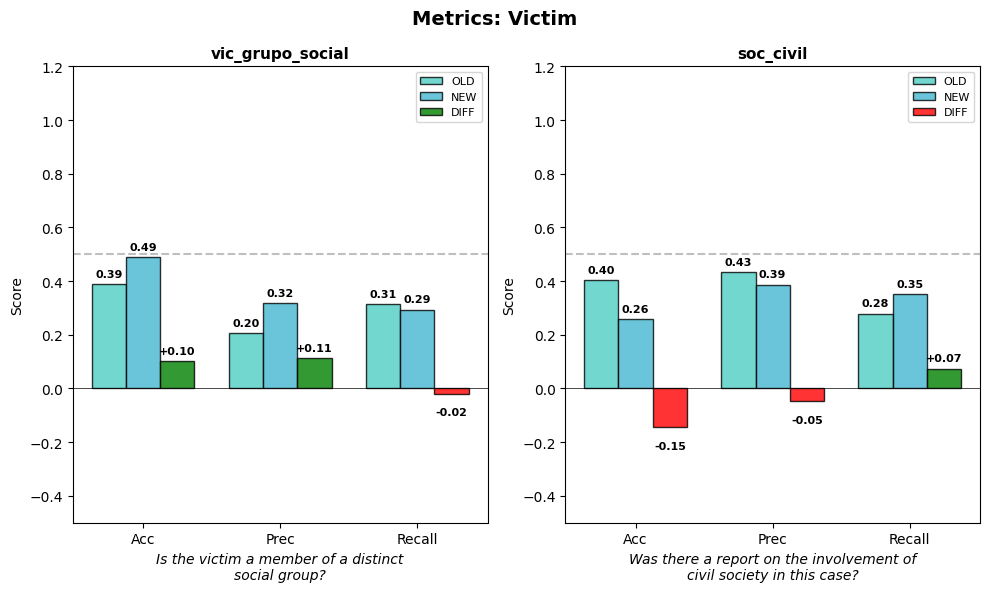

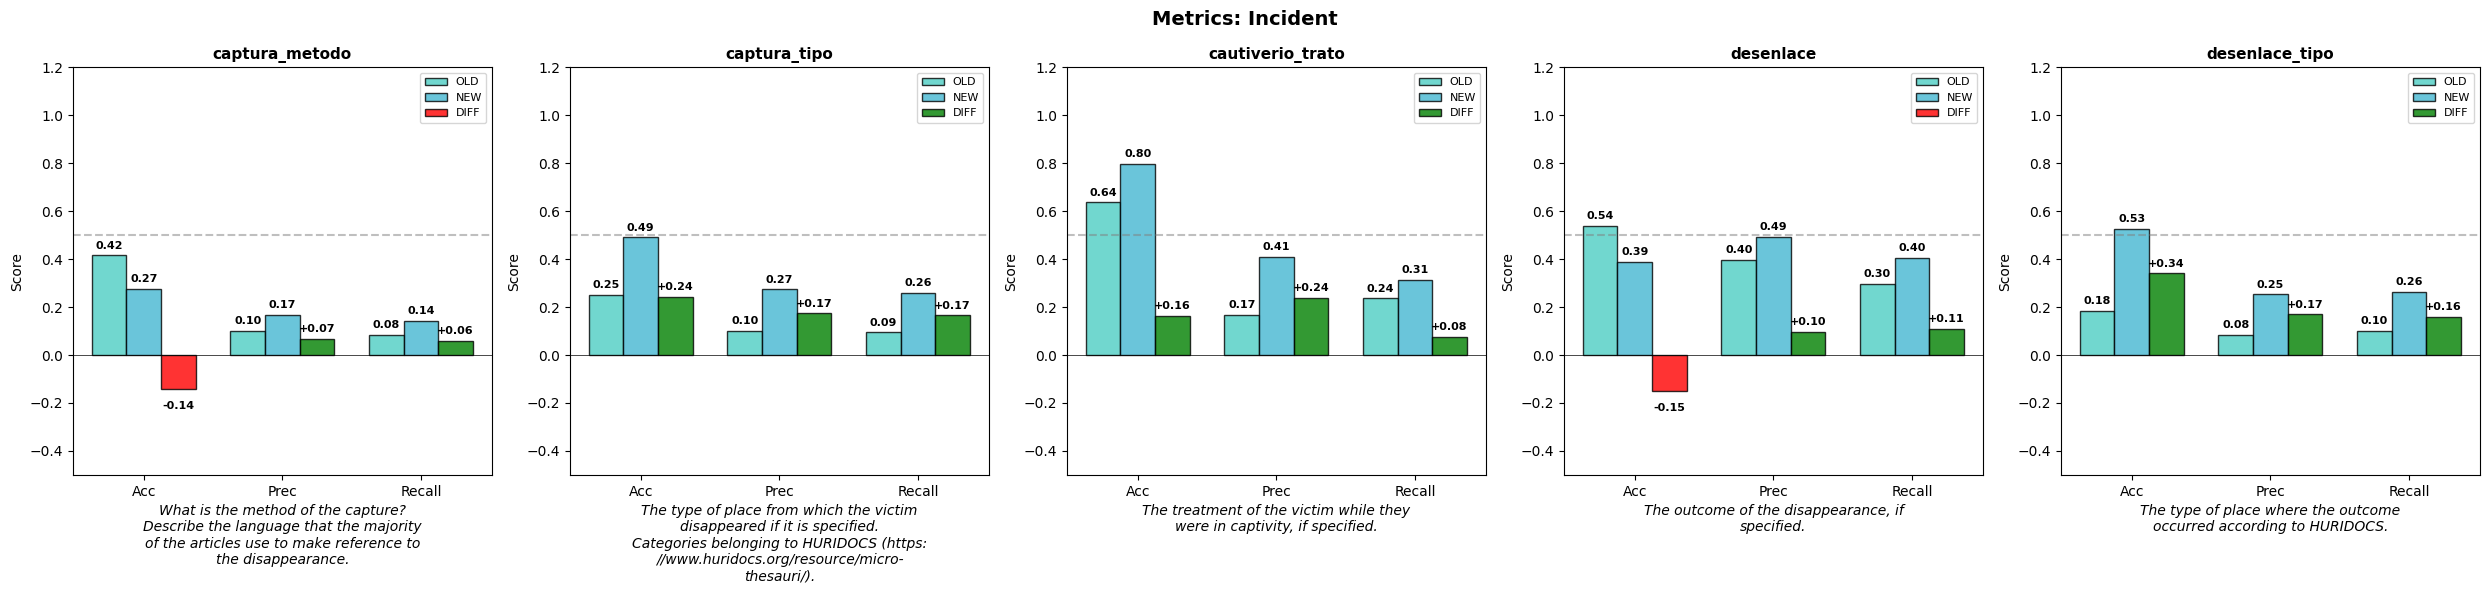

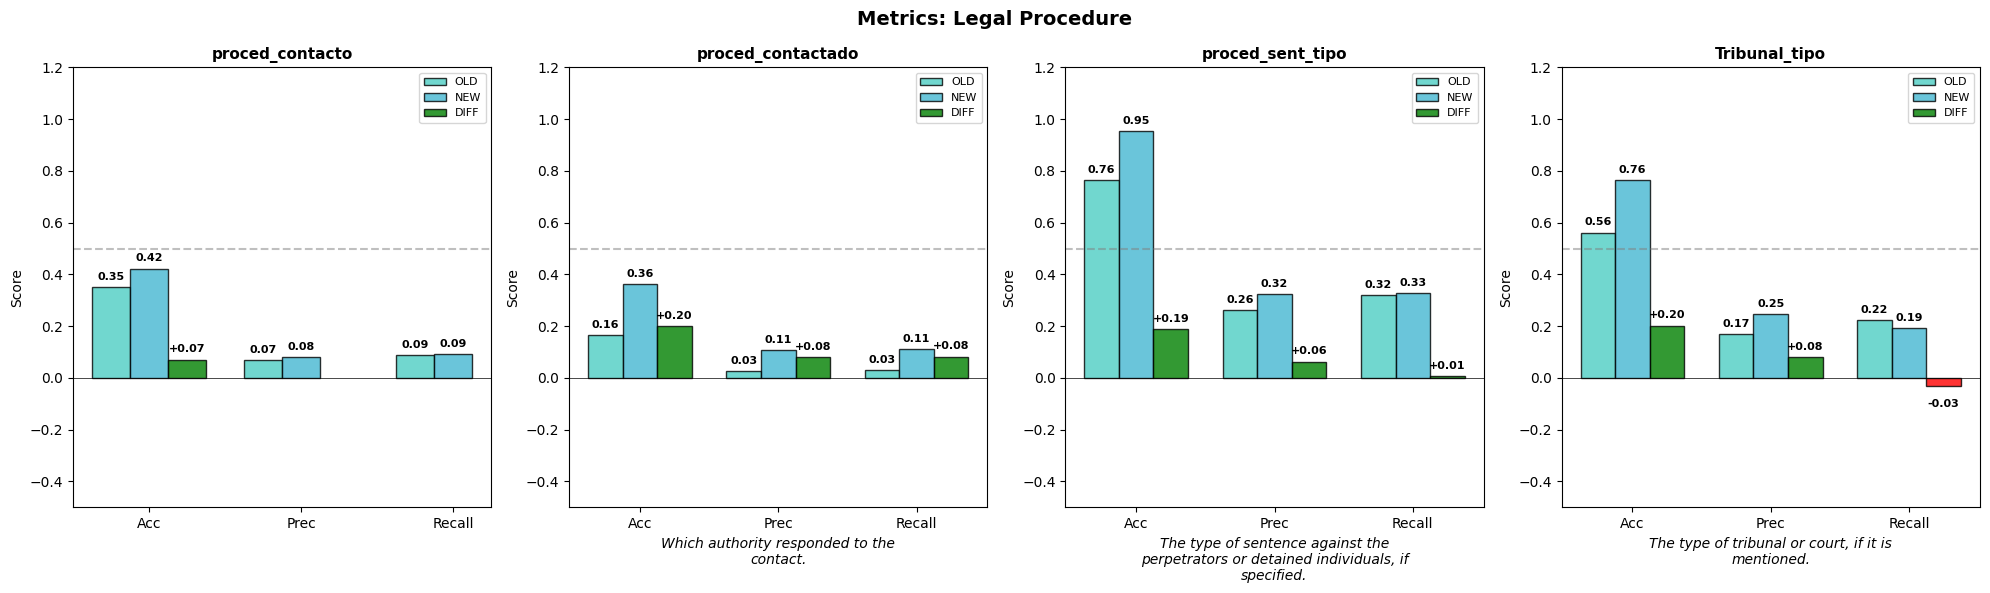

In [43]:
# =============================================================================
# NEW PLOTS: Metrics by Group (4 plots, each with subplots per label)
# =============================================================================
# Groups based on log_7.md classification (using merged labels):
#   Entity - Perpetrator: perp_tipo, amenaza_quien
#   Entity - Victim: vic_grupo_social, soc_civil
#   Event - Incident: captura_metodo, captura_tipo, cautiverio_trato, desenlace, desenlace_tipo
#   Event - Legal Procedure: proced_contacto, proced_contactado, proced_sent_tipo, Tribunal_tipo

# Load context definitions from taxonomy
CONTEXT_DEFINITIONS = taxonomy["context_definitions"]

LABEL_GROUPS = {
    "Perpetrator": ["perp_tipo", "amenaza_quien"],
    "Victim": ["vic_grupo_social", "soc_civil"],
    "Incident": ["captura_metodo", "captura_tipo", "cautiverio_trato", "desenlace", "desenlace_tipo"],
    "Legal_Procedure": ["proced_contacto", "proced_contactado", "proced_sent_tipo", "Tribunal_tipo"],
}


def get_metric_values(label: str, metric: str, df_old, df_new, df_diff):
    """Get OLD, NEW, DIFF values for a given label and metric."""
    # Get OLD value (for merged labels, use avg of original labels)
    if label == "perp_tipo":
        vals = [df_old.loc[l, metric] for l in ["perp_tipo1", "perp_tipo2"] if l in df_old.index]
        old_val = sum(vals) / len(vals) if vals else 0.0
    elif label == "proced_contacto":
        vals = [df_old.loc[l, metric] for l in ["proced_contacto1", "proced_contacto2"] if l in df_old.index]
        old_val = sum(vals) / len(vals) if vals else 0.0
    else:
        old_val = df_old.loc[label, metric] if label in df_old.index else 0.0
    
    # Get NEW value
    new_val = df_new.loc[label, metric] if label in df_new.index else 0.0
    
    # Get DIFF value
    diff_col = f"Δ {metric}"
    diff_val = df_diff.loc[label, diff_col] if label in df_diff.index and diff_col in df_diff.columns else new_val - old_val
    
    return old_val, new_val, diff_val


def plot_metrics_by_group(group_name: str, labels: list, df_old, df_new, df_diff, output_path: Path, context_defs: dict):
    """
    Plot metrics comparison (Accuracy, Precision, Recall) for a group of labels.
    Each label gets a subplot with grouped bars: OLD/NEW/DIFF for each metric.
    """
    import textwrap
    import numpy as np
    
    n_labels = len(labels)
    fig, axes = plt.subplots(1, n_labels, figsize=(5 * n_labels, 6))
    
    # Handle single subplot case
    if n_labels == 1:
        axes = [axes]
    
    metrics = ["Accuracy", "Precision", "Recall"]
    bar_width = 0.25
    x = np.arange(3)  # 3 metrics
    
    for idx, label in enumerate(labels):
        ax = axes[idx]
        
        # Get values for each metric
        old_vals, new_vals, diff_vals = [], [], []
        for metric in metrics:
            old_v, new_v, diff_v = get_metric_values(label, metric, df_old, df_new, df_diff)
            old_vals.append(old_v)
            new_vals.append(new_v)
            diff_vals.append(diff_v)
        
        # Plot grouped bars
        bars_old = ax.bar(x - bar_width, old_vals, bar_width, label="OLD", color="#4ecdc4", edgecolor="black", alpha=0.8)
        bars_new = ax.bar(x, new_vals, bar_width, label="NEW", color="#45b7d1", edgecolor="black", alpha=0.8)
        diff_colors = ["green" if v >= 0 else "red" for v in diff_vals]
        bars_diff = ax.bar(x + bar_width, diff_vals, bar_width, label="DIFF", color=diff_colors, edgecolor="black", alpha=0.8)
        
        # Add value labels
        for bars, vals, is_diff in [(bars_old, old_vals, False), (bars_new, new_vals, False), (bars_diff, diff_vals, True)]:
            for bar, val in zip(bars, vals):
                y_pos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.05
                va = "bottom" if val >= 0 else "top"
                fmt = f"{val:+.2f}" if is_diff else f"{val:.2f}"
                ax.text(bar.get_x() + bar.get_width()/2, y_pos, fmt,
                        ha="center", va=va, fontsize=8, fontweight="bold")
        
        ax.set_ylim(-0.5, 1.2)
        ax.set_xticks(x)
        ax.set_xticklabels(["Acc", "Prec", "Recall"], fontsize=10)
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_ylabel("Score")
        ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
        ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
        ax.legend(loc="upper right", fontsize=8)
        
        # Add context definition below each subplot
        definition = context_defs.get(label, "")
        if definition:
            wrapped = "\n".join(textwrap.wrap(definition.strip(), width=40))
            ax.set_xlabel(wrapped, fontsize=10, style="italic", color="black")
    
    plt.suptitle(f"Metrics: {group_name.replace('_', ' ')}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_path / f"metrics_{group_name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Generate 4 plots
for group_name, labels in LABEL_GROUPS.items():
    plot_metrics_by_group(group_name, labels, df_old, df_new, df_diff, PLOT_PATH, CONTEXT_DEFINITIONS)